<a href="https://colab.research.google.com/github/Hnf124/Tugas_1_Kecerdasan_Buatan_Hanif/blob/main/DeteksiClickbaitJudulBerita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import re
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix
from nltk.tokenize import word_tokenize
from keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.models import Model
from keras.layers import Input, Dense, LSTM, Dropout, concatenate
from tensorflow.keras.layers import Embedding
from keras.utils import plot_model
nltk.download('punkt_tab')

df = pd.read_csv('all_agree.csv')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
print(df['label_score'].value_counts())

label_score
0    5297
1    3316
Name: count, dtype: int64


In [3]:
def find_punc(x, punc):
    count = 0
    for char in x:
        if char == punc:
            count += 1
    return count
def find_uppercase(x):
    count = 0
    for char in x:
        if char.isupper():
            count += 1
    return count
def find_lowercase(x):
    count = 0
    for char in x:
        if char.islower():
            count += 1
    return count
def find_number(x):
    import re
    return len(re.findall('[0-9]', x))

In [4]:
df['comma_count'] = df['title'].apply(lambda x: find_punc(x, ','))
df['stop_count'] = df['title'].apply(lambda x: find_punc(x, '.'))
df['question_count'] = df['title'].apply(lambda x: find_punc(x, '?'))
df['exclamation_count'] = df['title'].apply(lambda x: find_punc(x, '!'))
df['apostrophe_count'] = df['title'].apply(lambda x: find_punc(x, "'"))
df['colon_count'] = df['title'].apply(lambda x: find_punc(x, ':'))
df['semicolon_count'] = df['title'].apply(lambda x: find_punc(x, ';'))
df['uppercase_count'] = df['title'].apply(lambda x: find_uppercase(x))
df['lowercase_count'] = df['title'].apply(lambda x: find_lowercase(x))
df['number_count'] = df['title'].apply(lambda x: find_number(x))

In [5]:
print(df.shape)

(8613, 13)


In [6]:
def clean(text):
    # Lowering letters
    text = text.lower()
    # Removing punctuations
    text = re.sub(r'[!.,?;:"]', '', text)
    # Tokenization
    word_tokens = word_tokenize(text)
    # Joining words
    text = ' '.join(word_tokens)
    return text

In [7]:
df['cleaned_title'] = df['title'].apply(clean)

In [8]:
df[['title', 'cleaned_title']]

,title,cleaned_title
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",masuk radar pilwalkot medan menantu jokowi ber...
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,malaysia sudutkan ri isu kabut asap hingga inv...
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,viral driver ojol di bekasi antar pesanan maka...
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",kemensos salurkan rp 73 m bagi korban kerusuha...
4,MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...,mpr amandemen uud 1945 tak akan melebar ke man...
...,...,...
8608,Twice Rilis Teaser MV 'Feel Special' Jelang Co...,twice rilis teaser mv 'feel special ' jelang c...
8609,"Asap Karhutla Riau Mulai Merambah Ke Nias, BM...",asap karhutla riau mulai merambah ke nias bmkg...
8610,"Tolak RUU Pertanahan, Ribuan Petani Siap Gelar...",tolak ruu pertanahan ribuan petani siap gelar ...
8611,Ada Niat Tambah Momongan Tanpa Ikut Program Ha...,ada niat tambah momongan tanpa ikut program ha...


In [9]:
df.columns

Index(['title', 'label', 'label_score', 'comma_count', 'stop_count',
       'question_count', 'exclamation_count', 'apostrophe_count',
       'colon_count', 'semicolon_count', 'uppercase_count', 'lowercase_count',
       'number_count', 'cleaned_title'],
      dtype='object')

In [10]:
X = df.iloc[:,3:]
y = df.iloc[:,2]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=77)

In [33]:
print(X_train.shape)
print(y_test.shape)

(6890, 11)
(1723,)


In [17]:
X_train_title = X_train['cleaned_title']
X_test_title = X_test['cleaned_title']

X_train_punc = X_train.drop('cleaned_title', axis=1)
X_test_punc = X_test.drop('cleaned_title', axis=1)

In [18]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_title)

X_train_title = tokenizer.texts_to_sequences(X_train_title)
X_test_title = tokenizer.texts_to_sequences(X_test_title)

In [19]:
tokenizer.word_index

{'di': 1,
 'ini': 2,
 'dan': 3,
 'yang': 4,
 "'": 5,
 'ke': 6,
 'jadi': 7,
 'kpk': 8,
 '2019': 9,
 'indonesia': 10,
 'tak': 11,
 'untuk': 12,
 'dengan': 13,
 'habibie': 14,
 'dari': 15,
 'dpr': 16,
 'polisi': 17,
 'jokowi': 18,
 'saat': 19,
 'soal': 20,
 'akan': 21,
 'uu': 22,
 'baru': 23,
 'minta': 24,
 'anak': 25,
 'ada': 26,
 'mahasiswa': 27,
 'bisa': 28,
 'hingga': 29,
 'demo': 30,
 'bikin': 31,
 '3': 32,
 'asap': 33,
 'vs': 34,
 'kota': 35,
 'revisi': 36,
 '5': 37,
 'gara': 38,
 'hari': 39,
 'papua': 40,
 'bj': 41,
 '4': 42,
 'tahun': 43,
 '2': 44,
 'usai': 45,
 'liga': 46,
 'sebut': 47,
 'warga': 48,
 'bakal': 49,
 'orang': 50,
 'rumah': 51,
 'sinopsis': 52,
 '1': 53,
 'begini': 54,
 'dalam': 55,
 'dunia': 56,
 'gelar': 57,
 'kabut': 58,
 'jakarta': 59,
 'siap': 60,
 'ibu': 61,
 'rp': 62,
 'karena': 63,
 'foto': 64,
 'jalan': 65,
 'mobil': 66,
 'sudah': 67,
 'apa': 68,
 'lebih': 69,
 'dki': 70,
 'pemerintah': 71,
 'episode': 72,
 '2020': 73,
 'korban': 74,
 'masih': 75,
 'kasus':

In [20]:
vocab_size = len(tokenizer.word_index)
vocab_size

12509

In [21]:
lengths = []
for sentence in X_train_title:
    lengths.append(len(sentence))

print('Longest sentence\t:', max(lengths))
print('Shortest sentence\t:', min(lengths))
print('Average length\t\t:', np.mean(lengths))

Longest sentence	: 19
Shortest sentence	: 2
Average length		: 9.792162554426705


In [27]:
X_train_title = sequence.pad_sequences(X_train_title, maxlen=19)
X_test_title = sequence.pad_sequences(X_test_title, maxlen=19)

In [30]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train.values
)
class_weights

array([0.80868545, 1.30988593])

In [31]:
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.8086854460093896), 1: np.float64(1.3098859315589353)}

In [32]:
print(X_train_title.shape)
print(X_test_title.shape)

(6890, 19)
(1723, 19)


In [34]:
tf.random.set_seed(99)

lstm_input = Input(shape=(19,))  # Input layer dengan panjang urutan 19
lstm = Embedding(input_dim=vocab_size+1, output_dim=32, input_length=19)(lstm_input)
lstm = LSTM(3)(lstm)
lstm = Dropout(rate=0.5)(lstm)
lstm = Dense(3, activation='sigmoid')(lstm)

lstm_model = Model(inputs=lstm_input, outputs=lstm)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [35]:
dense_input = Input(shape=(10,))
dense = Dropout(rate=0.5)(dense_input)
dense = Dense(3, activation='sigmoid')(dense)
dense_model = Model(inputs=dense_input, outputs=dense)

In [36]:
print(X_train_punc.shape)
print(X_test_punc.shape)

(6890, 10)
(1723, 10)


In [37]:
concat = concatenate([lstm_model.output, dense_model.output])
concat = Dense(6, activation='sigmoid')(concat)
concat = Dense(1, activation='sigmoid')(concat)
model = Model(inputs=[lstm_model.input, dense_model.input], outputs=concat)

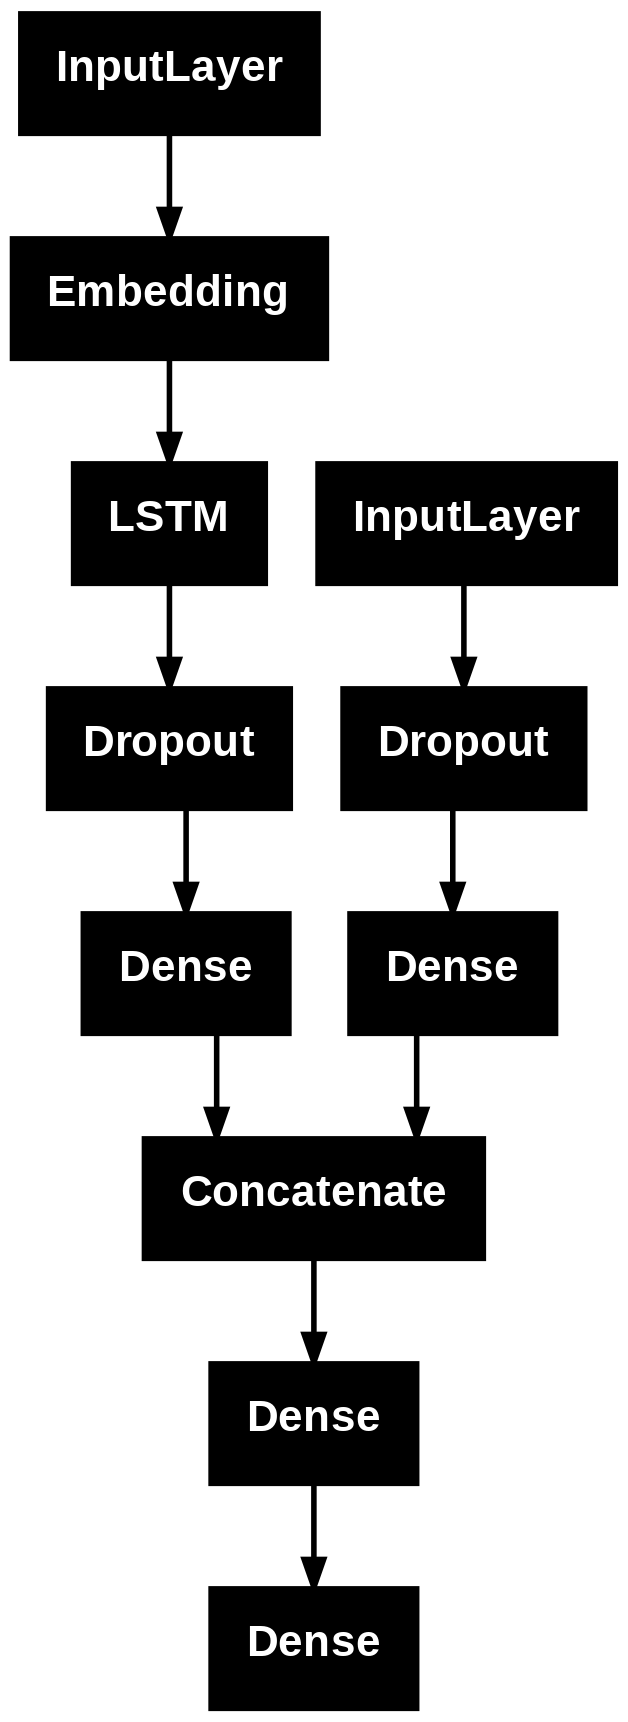

In [40]:
plot_model(model)

In [38]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['acc'])

In [39]:
history = model.fit([X_train_title, X_train_punc], y_train,
                    epochs=4, batch_size=64,
                    class_weight=class_weight_dict,
                    validation_data=([X_test_title, X_test_punc], y_test))

Epoch 1/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - acc: 0.3821 - loss: 0.6982 - val_acc: 0.3981 - val_loss: 0.7019
Epoch 2/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.5270 - loss: 0.6881 - val_acc: 0.5020 - val_loss: 0.6861
Epoch 3/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.7456 - loss: 0.6730 - val_acc: 0.8532 - val_loss: 0.6657
Epoch 4/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - acc: 0.8467 - loss: 0.6446 - val_acc: 0.8845 - val_loss: 0.6299


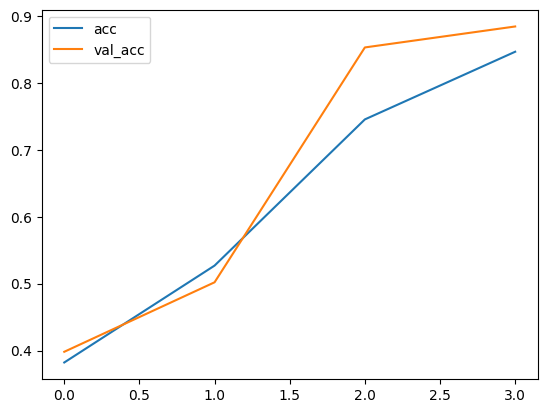

In [41]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.legend(['acc', 'val_acc'])

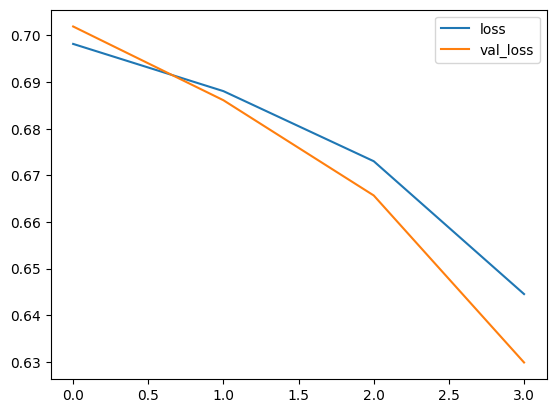

In [42]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss', 'val_loss'])